In [1]:
import tensorflow as tf
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from qkeras import *
from tensorflow.keras import layers, models


2026-06-19 14:16:07.369764: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-19 14:16:07.386380: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-19 14:16:07.501727: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-19 14:16:07.502823: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-19 14:16:08.079635: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:3

In [2]:
data = sio.loadmat('../data/sat-6-full.mat')
X_train = data['train_x']
y_train = data['train_y']
X_test = data['test_x']
y_test = data['test_y']

X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255

y_train = y_train.astype(np.float32)
y_test = y_test.astype(np.float32)

X_train = np.transpose(X_train, (3, 0, 1, 2))
X_test  = np.transpose(X_test,  (3, 0, 1, 2))

y_train = np.transpose(y_train, (1, 0))
y_test  = np.transpose(y_test,  (1, 0))

In [3]:
def get_quantizers(qbits):
    
    if qbits == 1:
        quant_w = quantizers.binary(alpha=1)
        quant_a = quantizers.binary(alpha=1)

    else:
        quant_w = quantizers.quantized_bits(qbits, 0, alpha=1)
        quant_a = quantizers.quantized_bits(qbits, 0, alpha=1)

    return quant_w, quant_a


def build_qmodel(qbits):

    quant_w, quant_a = get_quantizers(qbits)

    model = models.Sequential()

    model.add(layers.Input(shape=(28, 28, 4)))

    model.add(QConv2D(
        32, (3,3),
        strides=2,
        padding="same",
        kernel_quantizer=quant_w,
        bias_quantizer=quant_w,
    ))
    model.add(QActivation(quant_a))

    model.add(QConv2D(
        64, (1,1),
        strides=1,
        padding="valid",
        kernel_quantizer=quant_w,
        bias_quantizer=quant_w,
    ))
    model.add(QActivation(quant_a))

    model.add(layers.Flatten())

    model.add(QDense(
        128,
        kernel_quantizer=quant_w,
        bias_quantizer=quant_w,
    ))
    model.add(QActivation(quant_a))

    model.add(QDense(
        6,
        kernel_quantizer=quant_w,
        bias_quantizer=quant_w,
        activation="softmax"
    ))

    return model



In [4]:
def train_model(qbits, X_train, y_train, X_test, y_test):

    model = build_qmodel(qbits)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(3e-4),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        X_train,
        y_train,
        batch_size=512,
        epochs=30,
        validation_data=(X_test, y_test),
        verbose=1
    )

    loss, acc = model.evaluate(X_test, y_test, verbose=0)

    return model, history, acc

In [5]:
model_8 = build_qmodel(8)
model_4 = build_qmodel(4)
model_2 = build_qmodel(2)
model_1 = build_qmodel(1)


/home/fauri/Documentos/hls4ml/.venv_hls4ml_t/lib/python3.10/site-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer HeNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


In [6]:
results = {}

for bits in [8, 4, 2, 1]:

    model, history, acc = train_model(
        bits,
        X_train,
        y_train,
        X_test,
        y_test
    )

    results[bits] = {
        "model": model,
        "accuracy": acc,
        'history': history
    }

    print(f"{bits} bits -> {acc:.4f}")

Epoch 1/30
633/633 [==============================] - 22s 33ms/step - loss: 0.2966 - accuracy: 0.8925 - val_loss: 0.2088 - val_accuracy: 0.9350
Epoch 2/30
633/633 [==============================] - 21s 32ms/step - loss: 0.1892 - accuracy: 0.9347 - val_loss: 0.1826 - val_accuracy: 0.9402
Epoch 3/30
633/633 [==============================] - 20s 32ms/step - loss: 0.1993 - accuracy: 0.9278 - val_loss: 0.2022 - val_accuracy: 0.9336
Epoch 4/30
633/633 [==============================] - 21s 32ms/step - loss: 0.2024 - accuracy: 0.9301 - val_loss: 0.1927 - val_accuracy: 0.9410
Epoch 5/30
633/633 [==============================] - 21s 33ms/step - loss: 0.1922 - accuracy: 0.9329 - val_loss: 0.1974 - val_accuracy: 0.9166
Epoch 6/30
633/633 [==============================] - 21s 33ms/step - loss: 0.1913 - accuracy: 0.9342 - val_loss: 0.1857 - val_accuracy: 0.9319
Epoch 7/30
633/633 [==============================] - 21s 33ms/step - loss: 0.2050 - accuracy: 0.9280 - val_loss: 0.1968 - val_accuracy:

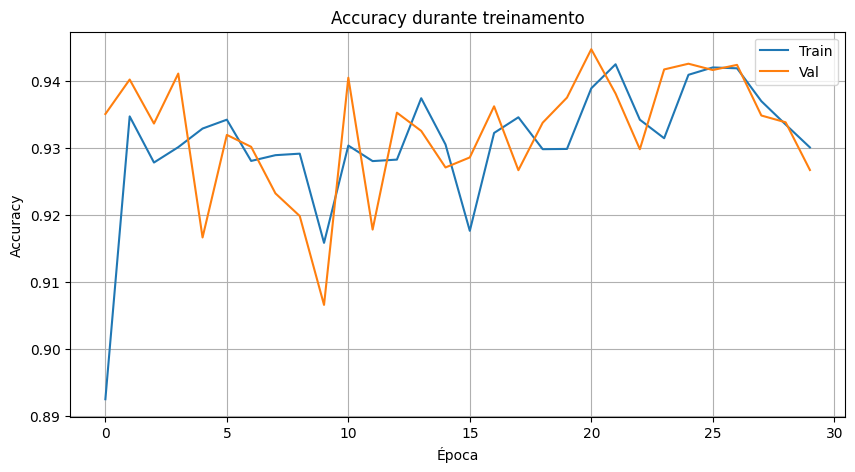

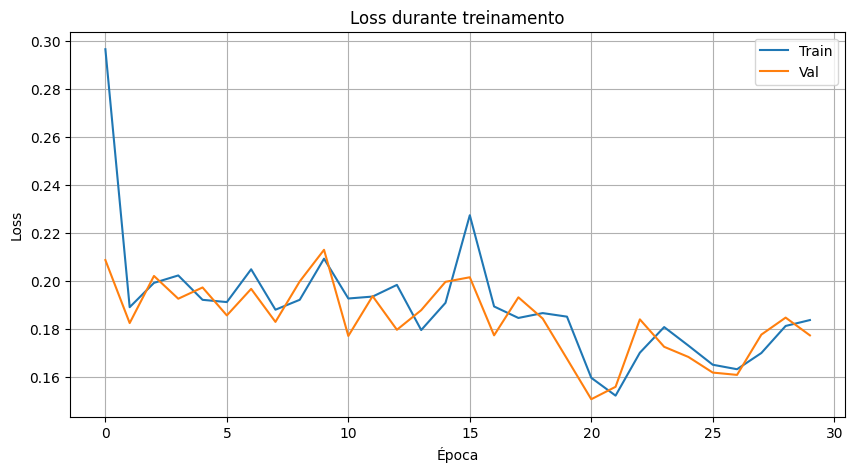

In [11]:
def plot_history(history):
    # Plotar acurácia
    plt.figure(figsize=(10,5))

    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Val')

    plt.xlabel('Época')
    plt.ylabel('Accuracy')
    plt.title('Accuracy durante treinamento')
    plt.legend()
    plt.grid(True)

    plt.show()

    # Plotar loss
    plt.figure(figsize=(10,5))

    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Val')

    plt.xlabel('Época')
    plt.ylabel('Loss')
    plt.title('Loss durante treinamento')
    plt.legend()
    plt.grid(True)

    plt.show()

plot_history(results[8]['history'])

In [ ]:
for bits in [8, 4, 2, 1]:
    print(f"Testando modelo com {bits} bits:")
    q_model = results[bits]['model']
    q_model.evaluate(X_test, y_test, verbose=0)

[0.5030978918075562, 0.7492098808288574]

Classe real: 5
Classe prevista: 5


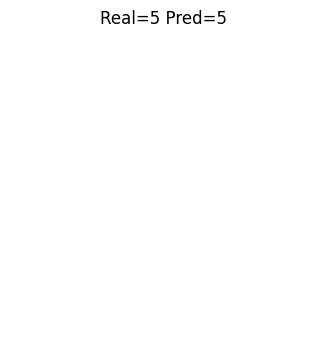

In [ ]:
q_model = results[1]['model']
idx = 80
img = X_test[idx]
label = y_test[idx]

pred = q_model.predict(
    np.expand_dims(img, axis=0),
    verbose=0
)

pred_class = np.argmax(pred)
true_class = np.argmax(label)

print("Classe real:", true_class)
print("Classe prevista:", pred_class)

plt.figure(figsize=(4,4))

plt.imshow(img[:, :, :3])

plt.title(
    f"Real={true_class} Pred={pred_class}"
)

plt.axis('off')
plt.show()

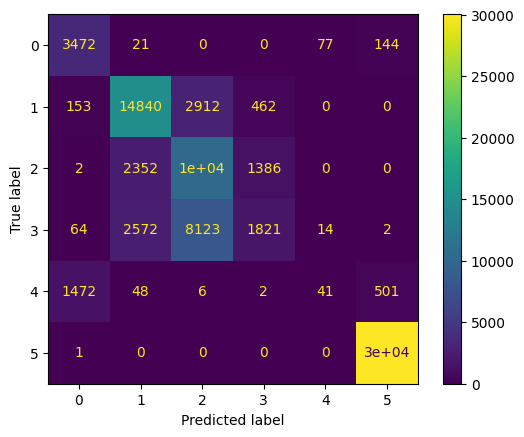

In [ ]:
q_model = results[1]['model']
y_pred = q_model.predict(X_test, verbose=0)

y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(cm)

disp.plot()
plt.show()

In [ ]:
for bits in [8, 4, 2, 1]:
    print(f"Testando modelo com {bits} bits:")
    q_model = results[bits]['model']

    preds = q_model.predict(X_test, verbose=0)

    preds = np.argmax(preds, axis=1)
    truth = np.argmax(y_test, axis=1)

    errors = np.where(preds != truth)[0]

    print("Número de erros:", len(errors))

Número de erros: 20314


In [ ]:
for bits in [8, 4, 2, 1]:
    print(f"Salvando modelo com {bits} bits:")
    results[bits]['model'].save(f"cnn_quant_{bits}bits.h5")


/home/fauri/Documentos/hls4ml/.venv_hls4ml_t/lib/python3.10/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
